# SentencePiece 프로젝트 - 네이버 영화리뷰 감정분석

1. SentencePiece 설치
2. SentencePiece 모델 학습
3. Tokenizer 함수 작성(프로젝트에서 요구한 조건 3개 맞춰서)
5. 네이버 영화리뷰 감정 분석 문제에 SentencePiece 적용해 보기 - SentencePiece 버전, Mecab 버전 둘 다
6. 두 버전 성능 비교
7. 마무리 정리

## SentencePiece 설치

KoNLPy(Mecab)이랑 SentencePiece 설치.

In [ ]:
# Mecab 설치
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh
%cd ..

# SentencePiece 설치 - 구글에서 공개한 Subword 토크나이저 라이브러리.
# WPM 계열 방식을 실제로 구현해놓은 라이브러리
!pip install sentencepiece

# 설치 끝나면 런타임 재시작 필요함 (런타임 → 세션 다시 시작). 재시작 후엔 이 셀 다시 안 돌려도 되고
# 바로 다음 셀부터 이어서 실행하면 된다.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 38.7 MB/s eta 0:00:00
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 30.28 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-09-03 00:57:27--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.26, 104.192.142.25, 104.192.142.24, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.26|:443... connected.
HTTP request sent, 

### 라이브러리 버전 확인

나중에 결과가 이상하게 나오면 버전 문제인지 코드 문제인지 구분하기 쉬우라고 버전을 미리 찍어둔다.

In [ ]:
import torch
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy
import sentencepiece as spm
import os, re, random, time

# 시드 고정 - 딥러닝은 가중치 초기화나 데이터 셔플에 랜덤이 섞여 있어서 시드를 안 고정하면
# 같은 코드를 돌려도 결과(정확도 등)가 매번 조금씩 바뀐다. 고정해두면 나중에 뭐가 문제였는지
# 추적하기 편해진다고 해서 넣었다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("konlpy:", konlpy.__version__)

# GPU 있으면 GPU로, 없으면 CPU로 자동 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용할 device:", device)

torch: 2.11.0+cu128
numpy: 2.1.3
matplotlib: 3.10.0
konlpy: 0.6.0
사용할 device: cuda


## 1.1 한국어-영어 병렬 코퍼스 준비

SentencePiece를 학습시키려면 재료가 되는 텍스트(코퍼스)가 필요하다. 2강에서 썼던 한국어-영어 병렬 말뭉치를 그대로 다시 쓴다.

다운로드 - 중복 제거 - 길이 필터링을 여기서 다시 한다.

In [ ]:
!wget -q https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz -O corpus.tar.gz
!tar -xzvf corpus.tar.gz

path_to_file = "korean-english-park.train.ko"
with open(path_to_file, "r") as f:
    raw = f.read().splitlines()
    # splitlines(): 파일 전체를 읽어서 줄바꿈 기준으로 잘라 리스트로 만들어줌. 원소 하나 = 문장 하나.

print("원본 데이터 크기:", len(raw))

korean-english-park.train.en
korean-english-park.train.ko
원본 데이터 크기: 94123


In [ ]:
# 중복 제거
# set으로 바꾸면 같은 원소는 하나만 남기 때문에 중복 문장이 자동으로 정리된다.
# set은 순서가 없어서 다시 list()로 감싸줬다.
cleaned_corpus = list(set(raw))
print("중복 제거 후 데이터 크기:", len(cleaned_corpus))

# 길이 기준 필터링 - 너무 짧은 문장이랑 너무 긴 문장 제외
max_len = 150
min_len = 10
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]
print("길이 필터링 후 최종 데이터 크기:", len(filtered_corpus))

중복 제거 후 데이터 크기: 77591
길이 필터링 후 최종 데이터 크기: 76908


## 2. SentencePiece 모델 학습

SentencePiece는 BPE랑 unigram(WPM이랑 비슷한 원리, 확률 기반) 두 방식 중에 골라서 쓸 수 있다. 요즘 나오는 사전학습 모델들이 거의 SentencePiece를 표준처럼 쓴다고 자료에 나와 있었다.

방금 만든 `filtered_corpus`로 실제로 학습을 돌려본다.

In [ ]:
temp_file = "korean-english-park.train.ko.temp"
vocab_size = 8000
# vocab_size - 최종 사전에 Subword 조각을 몇 개 담을지 정하는 값. BPE의 num_merges랑
# 비슷한 역할이라고 이해했다. 숫자가 크면 더 원래 단어에 가까운 조각들이, 작으면 더 잘게 쪼개진 조각들이 사전에 담긴다.

# SentencePiece는 파이썬 리스트가 아니라 파일을 입력으로 받기 때문에 filtered_corpus를 한 줄에
# 문장 하나씩 들어간 텍스트 파일로 먼저 저장해야 한다.
with open(temp_file, "w") as f:
    for row in filtered_corpus:
        f.write(str(row) + "\n")

# SentencePieceTrainer.Train()이 실제로 모델을 학습시키는 함수.
# --input: 학습용 텍스트 파일 / --model_prefix: 결과 파일 이름 접두사 / --vocab_size: 위에서 정한 사전 크기
# model_type을 따로 안 정하면 기본값이 unigram이라고 해서 그냥 기본값으로 뒀다.
spm.SentencePieceTrainer.Train(
    "--input={} --model_prefix=korean_spm --vocab_size={}".format(temp_file, vocab_size)
)

!ls -l korean_spm*
# korean_spm.model(토크나이저 모델 파일)이랑 korean_spm.vocab(사전 파일) 두 개가 생긴다.

-rw-r--r-- 1 root root 380936 Sep  3 01:00 korean_spm.model
-rw-r--r-- 1 root root 147830 Sep  3 01:00 korean_spm.vocab


### 학습된 모델 테스트

제대로 학습됐는지 문장 하나 넣어서 인코딩/디코딩 확인.

In [ ]:
s = spm.SentencePieceProcessor()
s.Load("korean_spm.model")

# sentence -> encoding
tokensIDs = s.EncodeAsIds("아버지가방에들어가신다.")
print("인코딩된 ID 시퀀스:", tokensIDs)

# sentence -> encoded pieces (숫자 대신 실제 조각 형태로 보기)
print("조각(piece) 형태:", s.SampleEncodeAsPieces("아버지가방에들어가신다.", -1, 0.1))

# encoding -> sentence 복원
print("복원된 문장:", s.DecodeIds(tokensIDs))

인코딩된 ID 시퀀스: [1202, 10, 318, 6, 3748, 10, 287, 31, 4]
조각(piece) 형태: ['▁', '아', '버', '지', '가', '방', '에', '들어', '가', '신', '다', '.']
복원된 문장: 아버지가방에들어가신다.


## 3. Tokenizer 함수 작성
앞에서 만든 `Tokenizer` 클래스, `tokenize()` 함수랑 비슷한 역할을 하되 SentencePiece에 맞게 새로 짜는 함수다. 자료에서 요구한 조건 3개를 지켜야 한다.

1. 매개변수로 문장 그대로의 list를 받는다 (이미 토큰화된 리스트 말고)
2. `word_index`, `index_word` 사전도 같이 만들어서 반환
3. 반환하는 tensor는 인코딩 + padding까지 끝낸 상태

In [ ]:
def sp_tokenize(s, corpus):
    # s: 위에서 만든, 학습이 끝난 SentencePieceProcessor 객체
    # corpus: 문장 그대로가 담긴 리스트 (조건 1)

    tensor = []
    for sen in corpus:
        # EncodeAsIds 한 번이면 쪼개고 ID로 바꾸는 것까지 다 됨.
        # Tokenizer.fit_on_texts() + texts_to_sequences()를 SentencePiece가 알아서 해주는 셈이다.
        tensor.append(s.EncodeAsIds(sen))

    # word_index / index_word 사전 만들기 (조건 2)
    # SentencePiece가 학습할 때 이미 korean_spm.vocab 파일에 "조각\t점수" 형태로 사전을 저장해뒀다.
    # 이 파일을 읽어서 우리 Tokenizer 클래스랑 같은 형태의 딕셔너리로 다시 만든다.
    with open("./korean_spm.vocab", "r") as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}
    for idx, line in enumerate(vocab):
        # vocab 파일에서 줄 번호(idx)가 곧 SentencePiece가 매긴 실제 토큰 ID랑 똑같다고 한다
        # (학습할 때 이 순서 그대로 저장되기 때문).
        word = line.split("\t")[0]
        word_index.update({word: idx})
        index_word.update({idx: word})

    # padding 처리 (조건 3)
    tensor = [torch.tensor(t, dtype=torch.long) for t in tensor]
    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

# 문장 5개로 잘 동작하는지 테스트
test_tensor, test_word_index, test_index_word = sp_tokenize(s, filtered_corpus[:5])
print("테스트 tensor shape:", test_tensor.shape)
print("사전 크기:", len(test_word_index))

테스트 tensor shape: torch.Size([5, 44])
사전 크기: 8000


## 4. 네이버 영화리뷰 감정 분석 문제에 SentencePiece 적용해 보기

이제 위에서 만든 SentencePiece 토크나이저를 실제 태스크(영화 리뷰 긍정/부정 분류)에 적용해본다.

한 가지 걸리는 부분: 방금 학습시킨 SentencePiece는 "한국어-영어 뉴스 병렬 코퍼스"로 학습한 거고, 실제로 적용할 데이터는 "영화 리뷰"라서 문체가 꽤 다르다(구어체, 신조어, 오타 많음). 이 domain mismatch가 성능에 영향을 주는지는 6번에서 비교할 때 같이 봐야 할 것 같다.

In [ ]:
# NSMC 공식 저장소에서 다운로드
!wget -q https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt -O ratings_train.txt
!wget -q https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt -O ratings_test.txt

def load_nsmc(path):
    # NSMC 파일은 "id\tdocument\tlabel" 탭 구분 텍스트 (label: 0=부정, 1=긍정)
    with open(path, "r", encoding="utf-8") as f:
        lines = f.read().splitlines()[1:]
        # [1:] - 첫 줄은 컬럼 이름이라서 뺐다.
    data = []
    for line in lines:
        parts = line.split("\t")
        if len(parts) != 3:
            # 리뷰 본문에 탭이 섞여서 3개로 안 쪼개지는 줄이 가끔 있어서 그냥 건너뜀
            continue
        _id, doc, label = parts
        if doc.strip() == "":
            continue
        data.append((doc, int(label)))
    return data

train_data = load_nsmc("ratings_train.txt")
test_data = load_nsmc("ratings_test.txt")
print("학습 데이터 크기:", len(train_data))
print("테스트 데이터 크기:", len(test_data))
print("샘플:", train_data[0])

# 긍정/부정 비율 확인 - 한쪽으로 너무 치우치면 모델이 한쪽만 찍어도 정확도가 높게 나올 수 있어서 확인해봤다.
pos_ratio = sum(l for _, l in train_data) / len(train_data)
print("학습 데이터 긍정 비율:", round(pos_ratio, 4))

학습 데이터 크기: 149995
테스트 데이터 크기: 49997
샘플: ('아 더빙.. 진짜 짜증나네요 목소리', 0)
학습 데이터 긍정 비율: 0.4988


In [ ]:
def clean_ko(text):
    # 2강에서 배운 노이즈 제거를 리뷰 데이터에 맞게 적용
    # 한글 자모/완성형, 영어, 숫자, 공백 빼고 다 지움
    # (ㅋㅋㅋ, ㅠㅠ 같은 자모 단독 표현도 감정 신호로 의미가 있을 것 같아서 자모까지는 허용해줬다)
    text = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9 ]", " ", text)
    # 위에서 지우고 나면 공백이 여러 개 겹칠 수 있어서 하나로 정리
    text = re.sub(r"\s+", " ", text).strip()
    return text

random.shuffle(train_data)
random.shuffle(test_data)

train_texts = [clean_ko(d) for d, l in train_data]
train_labels = [l for d, l in train_data]
test_texts = [clean_ko(d) for d, l in test_data]
test_labels = [l for d, l in test_data]

print("정제 예시:", train_data[0][0], "->", train_texts[0])

정제 예시: 개재미없다. 감독의 연출력의 한계 -> 개재미없다 감독의 연출력의 한계


## 5. 텍스트 분류 모델 정의

Embedding(2강 3번째 스텝에서 배운, 단어를 분산 표현 벡터로 바꿔주는 레이어) + LSTM + Linear 이렇게 세 개 쌓은 분류기를 만든다.

LSTM은 사실 아직 수업에서 정식으로 배운 게 아니라서 완전히 자신 있게 설명은 못 하겠는데, 찾아보니까 문장을 순서대로 읽으면서 지금까지 읽은 내용을 계속 요약해나가는 RNN 계열 레이어라고 한다. 어제 ELMo 배울 때도 양방향 LSTM 얘기가 잠깐 나왔었다. 여기서는 일단 "문장을 순서대로 읽어서 벡터 하나로 요약해주는 블랙박스" 정도로만 이해하고 썼다.

### pack_padded_sequence 관련해서 삽질한 부분

처음에 `pad_sequence`로 짧은 문장 뒤에 0을 채워서 텐서 크기를 맞췄는데, LSTM한테 "이 문장은 실제로 여기까지가 진짜야"라고 알려주는 걸 안 했더니 학습이 하나도 안 됐다. loss가 0.69 근처에서 안 떨어지고 정확도도 50% 근처(그냥 찍는 수준)에서 안 오르길래 한참 헤맸다. 찾아보니까 패딩까지 LSTM이 진짜 단어처럼 계속 읽어버리면 문장이 길 때(이 데이터는 100자 넘는 것도 있음) 학습 신호가 너무 희석돼서 이런 문제가 생긴다고 한다.

`pack_padded_sequence`가 각 문장의 진짜 길이를 LSTM한테 알려줘서 패딩 부분은 계산에서 빼주는 함수라고 해서 이걸 넣었더니 문제가 해결됐다.

In [ ]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        # 단어(정수 ID)를 embed_dim 차원 벡터로 바꿔주는 레이어
        # padding_idx=0 - 0번(패딩용 ID)에 해당하는 벡터는 항상 0으로 고정하고 학습도 안 시킴. 패딩은 의미가 없으니까.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 문장을 순서대로 읽으면서 hidden state를 갱신해나가는 레이어
        # batch_first=True - 입력 텐서 형태를 (배치크기, 문장길이, 임베딩차원) 순서로 맞춤
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # Dropout - 학습 중에 일부 뉴런을 무작위로 꺼서 특정 뉴런에 너무 의존하지 않게 하는 정규화 기법.
        # 3강에서 배운 개념. 데이터가 15만개나 있어도 과적합(어제 배운 개념) 줄이려고 넣었다.
        self.dropout = nn.Dropout(dropout)

        # LSTM이 요약해준 벡터를 받아서 부정(0)/긍정(1) 점수로 바꿔주는 레이어
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        # x: (배치크기, 최대문장길이) 형태의 정수 텐서
        # lengths: 배치 안 각 문장의 진짜 길이(패딩 제외)

        emb = self.embedding(x)
        # emb: (배치크기, 최대문장길이, embed_dim)

        # 패딩 부분을 계산에서 빼도록 LSTM한테 넘길 형태로 압축
        # enforce_sorted=False - 문장들이 길이순으로 미리 정렬 안 돼 있어도 알아서 처리해달라는 옵션
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # h는 각 문장을 끝까지 읽은 뒤의 최종 요약 벡터(hidden state)
        _, (h, c) = self.lstm(packed)

        # h 형태가 (LSTM 레이어 수, 배치크기, hidden_dim)인데 레이어를 1개만 썼으니 h[-1]로 꺼냄
        out = self.dropout(h[-1])
        out = self.fc(out)
        # out: (배치크기, num_classes) - 부정일 점수, 긍정일 점수
        return out

## 6. 인코딩 유틸리티 + 학습/평가 함수

SentencePiece 버전이랑 Mecab 버전 둘 다에서 재사용할 수 있게 "텍스트 목록 넣으면 (텐서, 길이) 튜플 반환하는 함수"랑 "모델 학습+평가하는 함수"를 미리 만들어둔다. 안 그러면 아래에서 거의 똑같은 코드를 두 번 복사해야 한다.

In [ ]:
MAX_TOK = 40
# 한 문장에서 최대 몇 개 토큰까지만 쓸지 정하는 값. 영화 리뷰가 대부분 짧은데 가끔 아주 긴 것도 있어서
# 너무 길면 LSTM이 끝까지 정보를 끌고 가기 힘들고 계산도 오래 걸린다. 감정(긍/부정) 신호는 보통 앞부분만
# 봐도 판단되는 경우가 많다고 해서 40 정도로 잘라도 괜찮을 거라 생각하고 정했다.

def encode_with_sp(sp_model, texts):
    seqs = []
    for t in texts:
        ids = sp_model.EncodeAsIds(t)[:MAX_TOK]
        if len(ids) == 0:
            # 정제 과정에서 내용이 통째로 사라지는 경우가 아주 가끔 있어서 예외 처리
            ids = [0]
        seqs.append(ids)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    tensor = pad_sequence([torch.tensor(s, dtype=torch.long) for s in seqs], batch_first=True, padding_value=0)
    return tensor, lengths


class SimpleVocab:
    # 위에서 쓴 Tokenizer 클래스랑 거의 비슷한데 MAX_TOK로 자르는 것까지 포함한 버전.
    # 형태소 분석기처럼 이미 토큰 리스트로 쪼개진 데이터를 다룰 때 쓴다.
    def __init__(self):
        self.word_index = {}
        self.index_word = {}

    def fit(self, tokenized_corpus):
        for tokens in tokenized_corpus:
            for tok in tokens[:MAX_TOK]:
                if tok not in self.word_index:
                    # 0번은 패딩 전용으로 비워두려고 1번부터 시작
                    self.word_index[tok] = len(self.word_index) + 1
        self.index_word = {idx: w for w, idx in self.word_index.items()}

    def encode(self, tokenized_corpus):
        seqs = []
        for tokens in tokenized_corpus:
            ids = [self.word_index.get(tok, 0) for tok in tokens[:MAX_TOK]]
            # 사전에 없는(학습 때 못 본) 형태소는 0번으로 처리
            if len(ids) == 0:
                ids = [0]
            seqs.append(ids)
        lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
        tensor = pad_sequence([torch.tensor(s, dtype=torch.long) for s in seqs], batch_first=True, padding_value=0)
        return tensor, lengths


class NSMCDataset(torch.utils.data.Dataset):
    # Dataset 상속해서 (입력 텐서, 길이, 라벨)을 묶어서 배치로 꺼낼 수 있게 하는 래퍼
    def __init__(self, tensor, lengths, labels):
        self.tensor = tensor
        self.lengths = lengths
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tensor[idx], self.lengths[idx], self.labels[idx]


def train_and_evaluate(train_tensor, train_lengths, train_labels,
                        test_tensor, test_lengths, test_labels,
                        vocab_size, epochs=6, batch_size=128, lr=1e-3, tag=""):
    # 두 토크나이저 버전 공통으로 쓸 학습+평가 루프
    train_ds = NSMCDataset(train_tensor, train_lengths, train_labels)
    test_ds = NSMCDataset(test_tensor, test_lengths, test_labels)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=batch_size)

    model = TextClassifier(vocab_size).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossfn = nn.CrossEntropyLoss()

    def evaluate():
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, l, y in test_loader:
                x, l, y = x.to(device), l.to(device), y.to(device)
                pred = model(x, l).argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)
        model.train()
        return correct / total

    best_acc = 0.0
    history = []
    start = time.time()
    for epoch in range(epochs):
        total_loss = 0
        for x, l, y in train_loader:
            x, l, y = x.to(device), l.to(device), y.to(device)
            opt.zero_grad()
            out = model(x, l)
            loss = lossfn(out, y)
            loss.backward()
            # gradient clipping - 기울기가 너무 커지는 걸 막아서 학습을 안정시키는 기법.
            # 위에서 pack_padded_sequence 안 썼을 때 학습이 안 되던 문제 잡으면서 같이 넣었다.
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            total_loss += loss.item()
        acc = evaluate()
        best_acc = max(best_acc, acc)
        history.append((epoch, total_loss / len(train_loader), acc))
        print(f"[{tag}] epoch {epoch+1}/{epochs}  loss={total_loss/len(train_loader):.4f}  test_acc={acc:.4f}")
    elapsed = time.time() - start
    print(f"[{tag}] 학습 소요 시간: {elapsed:.1f}초, 최고 test accuracy: {best_acc:.4f}")
    return {"history": history, "best_acc": best_acc, "elapsed": elapsed, "vocab_size": vocab_size}

## 7. SentencePiece 버전 학습 및 평가

목표는 test accuracy 80% 이상. 전체 학습 데이터(15만개) 다 쓴다. GPU면 epoch당 대충 수십 초~1-2분 정도 걸리는 것 같다. (CPU면 훨씬 오래 걸리니까 위에서 GPU로 바꿨는지 한 번 더 확인)

In [ ]:
sp_train_tensor, sp_train_lengths = encode_with_sp(s, train_texts)
sp_test_tensor, sp_test_lengths = encode_with_sp(s, test_texts)

# 사전 크기는 SentencePiece 학습할 때 정한 vocab_size(8000)랑 동일
sp_vocab_size = vocab_size

print("SentencePiece 학습용 tensor shape:", sp_train_tensor.shape)
print("SentencePiece 사전 크기:", sp_vocab_size)

sp_result = train_and_evaluate(
    sp_train_tensor, sp_train_lengths, train_labels,
    sp_test_tensor, sp_test_lengths, test_labels,
    vocab_size=sp_vocab_size, epochs=6, tag="SentencePiece"
)

SentencePiece 학습용 tensor shape: torch.Size([149995, 40])
SentencePiece 사전 크기: 8000
[SentencePiece] epoch 1/6  loss=0.4471  test_acc=0.8196
[SentencePiece] epoch 2/6  loss=0.3553  test_acc=0.8384
[SentencePiece] epoch 3/6  loss=0.3111  test_acc=0.8411
[SentencePiece] epoch 4/6  loss=0.2740  test_acc=0.8456
[SentencePiece] epoch 5/6  loss=0.2365  test_acc=0.8488
[SentencePiece] epoch 6/6  loss=0.2012  test_acc=0.8447
[SentencePiece] 학습 소요 시간: 63.4초, 최고 test accuracy: 0.8488


## 8. Mecab(형태소 분석기) 버전 학습 및 평가 - 비교용

데이터랑 모델 구조(TextClassifier)는 그대로 두고 토크나이저만 SentencePiece에서 Mecab으로 바꿔서 다시 학습한다. 다른 조건 다 고정하고 토크나이저만 바꿔야 공정하게 비교가 될 것 같아서 이렇게 했다.

In [ ]:
from konlpy.tag import Mecab
mecab = Mecab()

# 형태소 분석이 SentencePiece 인코딩보다 훨씬 느려서 전체 데이터를 한 번에 미리 다 쪼개둔다.
print("형태소 분석 진행 중... (전체 데이터라 몇 분 걸릴 수 있음)")
train_tokens = [mecab.morphs(t) for t in train_texts]
test_tokens = [mecab.morphs(t) for t in test_texts]

mecab_vocab = SimpleVocab()
mecab_vocab.fit(train_tokens)
# 사전은 반드시 학습 데이터로만 만든다. 테스트 데이터는 학습 때 못 본 척하고 encode만 해야
# 실제 배포됐을 때(처음 보는 문장 들어오는 상황)랑 비슷한 조건에서 성능을 잴 수 있다.

mecab_train_tensor, mecab_train_lengths = mecab_vocab.encode(train_tokens)
mecab_test_tensor, mecab_test_lengths = mecab_vocab.encode(test_tokens)
mecab_vocab_size = len(mecab_vocab.word_index) + 1  # +1은 0번(패딩/OOV) 자리

print("Mecab 학습용 tensor shape:", mecab_train_tensor.shape)
print("Mecab 사전 크기:", mecab_vocab_size)

mecab_result = train_and_evaluate(
    mecab_train_tensor, mecab_train_lengths, train_labels,
    mecab_test_tensor, mecab_test_lengths, test_labels,
    vocab_size=mecab_vocab_size, epochs=6, tag="Mecab"
)

형태소 분석 진행 중... (전체 데이터라 몇 분 걸릴 수 있음)
Mecab 학습용 tensor shape: torch.Size([149995, 40])
Mecab 사전 크기: 50540
[Mecab] epoch 1/6  loss=0.4186  test_acc=0.8418
[Mecab] epoch 2/6  loss=0.3116  test_acc=0.8560
[Mecab] epoch 3/6  loss=0.2575  test_acc=0.8607
[Mecab] epoch 4/6  loss=0.2118  test_acc=0.8594
[Mecab] epoch 5/6  loss=0.1701  test_acc=0.8583
[Mecab] epoch 6/6  loss=0.1345  test_acc=0.8573
[Mecab] 학습 소요 시간: 73.7초, 최고 test accuracy: 0.8607


## 9. 성능 비교

정확도만 볼 게 아니라 사전 크기, 학습 시간까지 같이 표로 정리해봤다.

In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "토크나이저": "SentencePiece (unigram)",
        "사전 크기": sp_result["vocab_size"],
        "최고 Test Accuracy": round(sp_result["best_acc"], 4),
        "학습 소요 시간(초)": round(sp_result["elapsed"], 1),
    },
    {
        "토크나이저": "Mecab (형태소 분석기)",
        "사전 크기": mecab_result["vocab_size"],
        "최고 Test Accuracy": round(mecab_result["best_acc"], 4),
        "학습 소요 시간(초)": round(mecab_result["elapsed"], 1),
    },
])
comparison

,토크나이저,사전 크기,최고 Test Accuracy,학습 소요 시간(초)
0,SentencePiece (unigram),8000,0.8488,63.4
1,Mecab (형태소 분석기),50540,0.8607,73.7


/tmp/ipykernel_885/3739891656.py:18: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_885/3739891656.py:18: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_885/3739891656.py:18: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.p

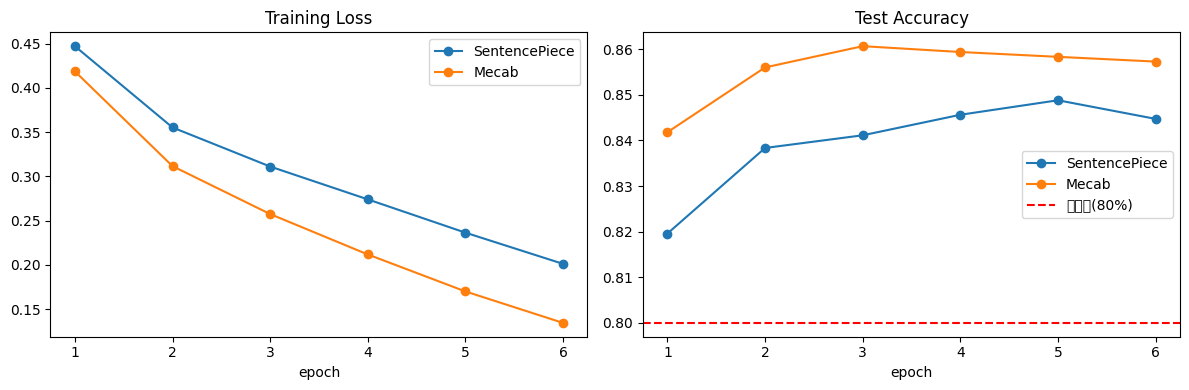

In [ ]:
# epoch별 loss/accuracy 곡선도 그려서 과적합(학습할수록 test acc가 오히려 떨어지는지) 여부까지 눈으로 봤다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for result, label in [(sp_result, "SentencePiece"), (mecab_result, "Mecab")]:
    epochs_ = [h[0] + 1 for h in result["history"]]
    losses_ = [h[1] for h in result["history"]]
    accs_ = [h[2] for h in result["history"]]
    axes[0].plot(epochs_, losses_, marker="o", label=label)
    axes[1].plot(epochs_, accs_, marker="o", label=label)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("epoch")
axes[1].axhline(0.8, color="red", linestyle="--", label="목표선(80%)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. 마무리

### 결과 확인
위 셀 다 돌리면 comparison 표에 숫자가 채워진다. `sp_result["best_acc"]`가 0.8(80%) 넘는지 확인해야 한다.
80% 안 넘으면 epochs를 늘리거나, hidden_dim/embed_dim을 키우거나, vocab_size를 조정해보면 될 것 같다.
최종적으로
0	SentencePiece (unigram)	8000	0.8488	63.4
1	Mecab (형태소 분석기)	50540	0.8607	73.7


